# Fire Spreading Advanced


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from data_preprocessing import sentinel_client

## Loading of data:

In [16]:
# Setup Authentication
client_id = 'sh-83b3baad-681c-49ff-967c-a1fe3eed19a4'
client_secret = 'L9cE8ASdvwyY64jWo8nUJQRIZ37A0XpS'
sc = sentinel_client(client_id=client_id, client_secret=client_secret)

## Model Class

In [ ]:
H, F, O, B = 0, 1, 2, 3

class FireSpreadingAdvanced:
    '''
    Class for....
    '''
    def __init__(self, n, m, max_H, max_F, max_O, mu_H, mu_O, dF, dO, ignition_temp=0.3, ignition_oxy = 0.76, ignition_fuel = 0.01, wind = [[1,1,1,1]], start_cells=[(0,0)], random_F=False, fuel_mask=None, water_mask=None):
        self.n = n
        self.m = m
        self.max_H = max_H
        self.max_F = max_F
        self.max_O = max_O
        self.mu_H = mu_H
        self.mu_O = mu_O
        self.water_mask = water_mask
        self.fuel_mask = fuel_mask

        if (sum(self.mu_O) != 1) or (sum(self.mu_H) != 1):
            print("Warning: The sum over the vector entries must be equal to one.")

        # wind?

        self.dF = dF
        self.dO = dO
        self.ignition_temp = ignition_temp
        self.ignition_oxy = ignition_oxy
        self.ignition_fuel = ignition_fuel

        self.state = np.zeros((n, m, 4))
 
        self.state[:, :, O] = self.max_O   

        for cell in start_cells:
            self.state[cell[0], cell[1], H] = self.max_H
            self.state[cell[0], cell[1], B] = 1
        
        if fuel_mask is not None:
            self.state[:, :, F] = np.maximum(0, fuel_mask)
            if water_mask is not None:
                self.state[:, :, F][water_mask > 0.1] = 0
        elif random_F:
            raw = np.random.uniform(0, 1, (n, m))

            for _ in range(2):
                raw = (
                    raw +
                    np.roll(raw, 1, axis=0) +
                    np.roll(raw, -1, axis=0) +
                    np.roll(raw, 1, axis=1) +
                    np.roll(raw, -1, axis=1)
                ) / 5

            self.state[:, :, F] = self.max_F * raw
        else:
            self.state[:, :, F] = self.max_F

        self.diff_state= np.copy(self.state)

    def diffuse_loop(self):
        '''
        Diffusion Phase
        bla bla
        Output:....
        '''

        diff_state = np.copy(self.state)

        for i in range(self.state.shape[0]):
            for j in range(self.state.shape[1]):

                up    = self.state[i-1, j] if i > 0 else self.state[i, j]
                down  = self.state[i+1, j] if i < n-1 else self.state[i, j]
                left  = self.state[i, j-1] if j > 0 else self.state[i, j]
                right = self.state[i, j+1] if j < m-1 else self.state[i, j]
                center = self.state[i, j]

                diff_state[i, j, H] = (
                    self.mu_H[0]*center[H] +
                    self.mu_H[1]*up[H] +
                    self.mu_H[2]*down[H] +
                    self.mu_H[3]*left[H] +
                    self.mu_H[4]*right[H]
                )

                diff_state[i, j, O] = (
                    self.mu_O[0]*center[O] +
                    self.mu_O[1]*up[O] +
                    self.mu_O[2]*down[O] +
                    self.mu_O[3]*left[O] +
                    self.mu_O[4]*right[O]
                )

        self.diff_state = diff_state
    



    def diffuse(self):
        diff_state = np.copy(self.state)

        H_state = self.state[:, :, H]
        O_state = self.state[:, :, O]

        # neighbors 
        H_up    = np.roll(H_state,  1, axis=0)
        H_down  = np.roll(H_state, -1, axis=0)
        H_left  = np.roll(H_state,  1, axis=1)
        H_right = np.roll(H_state, -1, axis=1)

        O_up    = np.roll(O_state,  1, axis=0)
        O_down  = np.roll(O_state, -1, axis=0)
        O_left  = np.roll(O_state,  1, axis=1)
        O_right = np.roll(O_state, -1, axis=1)

        diff_state[:, :, H] = (
            self.mu_H[0] * H_state +
            self.mu_H[1] * H_up +
            self.mu_H[2] * H_down +
            self.mu_H[3] * H_left +
            self.mu_H[4] * H_right
        )

        diff_state[:, :, O] = (
            self.mu_O[0] * O_state +
            self.mu_O[1] * O_up +
            self.mu_O[2] * O_down +
            self.mu_O[3] * O_left +
            self.mu_O[4] * O_right
        )

        self.diff_state = diff_state




    def burning_loop(self):
        '''
        Burning Phase
        bla bla
        Output:....
        '''

        state_new = np.copy(self.state)

        for i in range(self.state.shape[0]):
            for j in range(self.state.shape[1]):

                if self.state[i, j, B] == 1:
                    # burning cell

                    # 1. decrement the fuel and oxygen level
                    state_new[i, j, F] = max(0, self.state[i, j, F] - self.dF)
                    state_new[i, j, O] = max(0, self.diff_state[i, j, O] - self.dO)

                    # 2. set the heat level to maximum heat
                    state_new[i, j, H] = self.max_H

                    # 3. check if the fire is extinguished
                    if state_new[i, j, F] == 0 or state_new[i, j, O] == 0:
                        state_new[i, j, B] = 0

                    else:
                        # non-burning cell
                        # check conditions if the cell ignites, if the cell ignites set B to 1 and H to max_H

                        # also considering random ignition?
                        p = self.diff_state[i, j, H] / self.max_H     # the hotter it is, the higher the probability
                        # also cinsidering fuel and oxygen (fire-triangle)
                        p *= (self.state[i, j, F] / self.max_F)
                        p *= (self.diff_state[i, j, O] / self.max_O)

                        if ( # conditions for now:
                            (self.diff_state[i, j, H] > self.ignition_temp and
                            self.state[i, j, F] > self.ignition_fuel and
                            self.diff_state[i, j, O] > self.ignition_oxy)
                            #or np.random.rand() < p   # randomly ignites 
                        ):
                            state_new[i, j, B] = 1
                            state_new[i, j, H] = self.max_H
                        else:
                            state_new[i, j, H] = self.diff_state[i, j, H]
                            state_new[i, j, O] = self.diff_state[i, j, O]

            self.state = state_new


    def burning(self):

        state_new = np.copy(self.state)

        F_state = self.state[:, :, F]

        H_diff = self.diff_state[:, :, H]
        O_diff = self.diff_state[:, :, O]

        burning = (self.state[:, :, B] == 1) # burning cells

        # 1. decrement the fuel and oxygen level
        state_new[:, :, F][burning] = np.maximum(0, F_state[burning] - self.dF)
        state_new[:, :, O][burning] = np.maximum(0, O_diff[burning] - self.dO)

        # 2. set the heat level to maximum heat
        state_new[:, :, H][burning] = self.max_H

        # 3. check if the fire is extinguished
        extinguish = (state_new[:, :, F] == 0) | (state_new[:, :, O] == 0)
        state_new[:, :, B][burning & extinguish] = 0

        
        not_burning = ~burning # non burning cells

        # check conditions if the cell ignites, if the cell ignites set B to 1 and H to max_H
        # conditions:
        if self.water_mask is not None:
            ndwi_val = self.water_mask
            dynamic_ignition_temp = self.ignition_temp * (1.0 + ndwi_val)
        else:
            dynamic_ignition_temp = self.ignition_temp
        ignite = (
            (H_diff > dynamic_ignition_temp) &
            (F_state > self.ignition_fuel) &
            (O_diff > self.ignition_oxy)
        )

        # optional randomness??
        # rand = np.random.rand(*H_val.shape)
        # ignite = ignite & (rand < some_probability)

        state_new[:, :, B][not_burning & ignite] = 1
        state_new[:, :, H][not_burning & ignite] = self.max_H

        # update remaining cells
        state_new[:, :, H][not_burning & ~ignite] = H_diff[not_burning & ~ignite]
        state_new[:, :, O][not_burning & ~ignite] = O_diff[not_burning & ~ignite]

        self.state = state_new


    
    def make_rgb(self):
        fire = self.state[:, :, B]
        fuel = self.state[:, :, F]
        heat = self.state[:, :, H]

        rgb = np.zeros((self.state.shape[0], self.state.shape[1], 3))

        # red = fire + heat glow
        rgb[:, :, 0] = fire + 0.5 * heat

        # green = fuel
        rgb[:, :, 1] = fuel

        # blue = water or nothing
        if self.water_mask is not None:
            rgb[:, :, 2][self.water_mask > 0.5] = 1.0
        else:
            rgb[:, :, 2] = 0

        return np.clip(rgb, 0, 1)


    def run_simulation(self, T, gif_name = "fire"):

        fig, ax = plt.subplots()
        img = ax.imshow(self.make_rgb())

        frames = []

        for _ in range(T):
            #self.diffuse_loop()
            #self.burning_loop()

            self.diffuse()
            self.burning()

            frame = [ax.imshow(self.make_rgb(), animated=True)]
            frames.append(frame)

        ani = animation.ArtistAnimation(fig, frames, interval=100, blit=True)

        ani.save(gif_name+".gif", writer="pillow")
        

    

In [18]:
n, m = 100,100
max_H, max_F, max_O = 1.0, 1.0, 1.0
mu_O = [0.2,0.2,0.1,0.3,0.2]
mu_H = [0.2,0.2,0.1,0.3,0.2]
dF, dO = 0.02, 0.05
ignition_temp = 0.3
ignition_oxy = 0.76
ignition_fuel = 0.0
start_cells=[(n//2,m//2)]
random_F = True
wind = [[1,1,1,1]]

simple_fire_spreading = FireSpreadingAdvanced(n, m, max_H, max_F, max_O, mu_H, mu_O, dF, dO, ignition_temp, ignition_oxy, ignition_fuel, wind, start_cells, random_F)

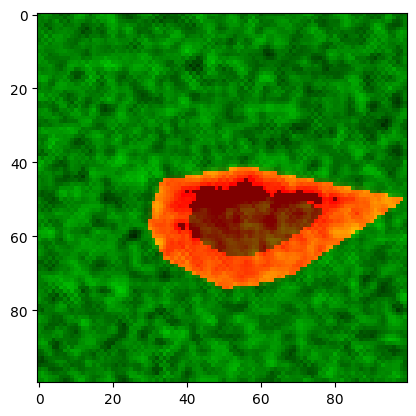

In [19]:
T = 50

simple_fire_spreading.run_simulation(T, gif_name = "fire")

In [20]:
fuel_data, water_data = sc.get_data(136.45, -36.1, 136.95, -35.75, "2019-05-01", "2019-05-15", 512, 442)

n = fuel_data.shape[0]
m = fuel_data.shape[1]
max_H, max_F, max_O = 1.0, 1.0, 1.0
mu_O = [0.2, 0.2, 0.1, 0.3, 0.2]
mu_H = [0.2, 0.2, 0.1, 0.3, 0.2]
dF, dO = 0.02, 0.05
ignition_temp = 0.3
ignition_oxy = 0.76
ignition_fuel = 0.0

wind = [[1,1,1,1]]
start_cells = [(n // 2, m // 2)]
random_F = False
fuel_mask = fuel_data
water_mask = water_data

sim_australia = FireSpreadingAdvanced(
    n, m, 
    max_H, max_F, max_O, 
    mu_H, mu_O, 
    dF, dO, 
    ignition_temp, ignition_oxy, ignition_fuel, 
    wind, 
    start_cells, 
    random_F, 
    fuel_mask, 
    water_mask
)

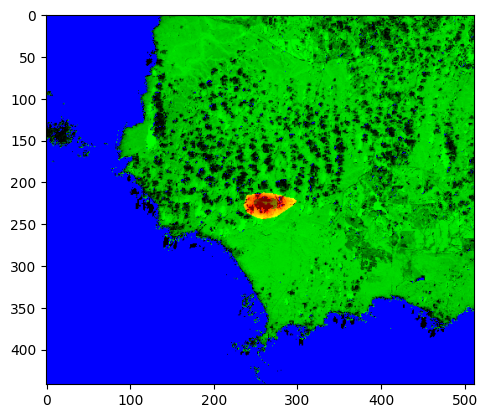

In [21]:
T = 50

sim_australia.run_simulation(T, gif_name="australia_fire")